# Exponential Smoothing Initialization & Model Performance Comparison

**Objective:** Compare the forecast accuracy ($R^2$, WMAPE) of Holt-Winters Exponential Smoothing models under four different initialization strategies through a synthetic dataset.

### Evaluated Model Configurations:
A. **`heuristic, init ⊂ train`**: Heuristic initialization; `init` data is included as a subset of `train`.

B. **`heuristic, init ⊄ train`**: Heuristic initialization; `init` and `train` datasets are mutually exclusive.

C. **`heuristic, no init`**: Automatic heuristic initialization carried out over the full `train` set.

D. **`estimated, no init`**: Joint regression/ML estimation of initial states over `train` without separate initialization.

---

### Key Findings:
* **A. `heuristic, init ⊂ train`** outperforms all models ($R^2 \approx 0.89$, WMAPE $\approx 0.09$) by combining trend dampening ($\phi$) with dynamic parameter adaptation.

| | heuristic, init ⊂ train | heuristic, init ⊄ train | heuristic, no init | estimated, no init |
| :--- | :---: | :---: | :---: | :---: |
| **level_factor** | 274.400 | 276.145 | 329.264 | 329.101 |
| **trend_factor** | 0.048 | 0.048 | 2.190 | 25.738 |
| **level_parameter** | 0.055 | 0.043 | 0.000 | 0.000 |
| **trend_parameter** | 0.000 | 0.000 | 0.000 | 0.000 |
| **dampening_parameter** | 0.986 | 0.923 | 0.925 | 0.800 |
| **seasonality_parameter** | 0.705 | 0.789 | 0.000 | 0.000 |
| **train_residual_mean** | -0.000 | 0.000 | -0.000 | 0.000 |
| **train_r2_score** | 0.823 | 0.612 | 0.810 | 0.833 |
| **train_WMAPE** | 0.107 | 0.158 | 0.114 | 0.111 |
| **test_residual_mean** | -15.042 | -19.044 | -19.401 | -20.666 |
| **test_r2_score** | **0.885** | 0.859 | 0.777 | 0.802 |
| **test_WMAPE** | **0.090** | 0.100 | 0.112 | 0.104 |

# Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc("axes.spines", top=False, right=False)
plt.style.use("ggplot")

from statsmodels.tsa.holtwinters import ExponentialSmoothing as ES
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# Synthetic Demand Data and Its Manipulation

In [2]:
## Init

# seed
np.random.seed(42)

# periods: 4 years, 48 months
year_num = 10
months = 12
period_num = year_num * months
periods = np.arange(1, year_num * months + 1)

# level
level = 250

# trend
trend = np.linspace(start=3, stop=0.5, num=period_num, endpoint=True)

# seasonality
seasonality_pat1 = np.array([0.7, 0.8, 1.1, 1.1, 1.2, 1.2, 1.6, 1.5, 1, 0.7, 0.6, 0.5])
seasonality_pat2 = np.array([0.6, 0.9, 1.1, 1.2, 1.7, 1.1, 1.2, 1.2, 1.1, 0.8, 0.6, 0.5])
print("Seasonality parameter average: ", sum(seasonality_pat1 + seasonality_pat2)/24)
seasonality = np.concatenate([np.tile(seasonality_pat1, int(year_num/2)), np.tile(seasonality_pat2, int(year_num/2))])

# noise
noise = np.random.normal(loc=0, scale=30, size=period_num)

# synthetic demand data
demand = (level + trend * periods) * seasonality + noise

# dataframe
df = pd.DataFrame({"months": periods, "act_demand": demand.round().astype(int)})

Seasonality parameter average:  1.0


In [3]:
df.head()

,months,act_demand
0,1,192
1,2,201
2,3,304
3,4,334
4,5,310


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   months      120 non-null    int64
 1   act_demand  120 non-null    int64
dtypes: int64(2)
memory usage: 2.0 KB


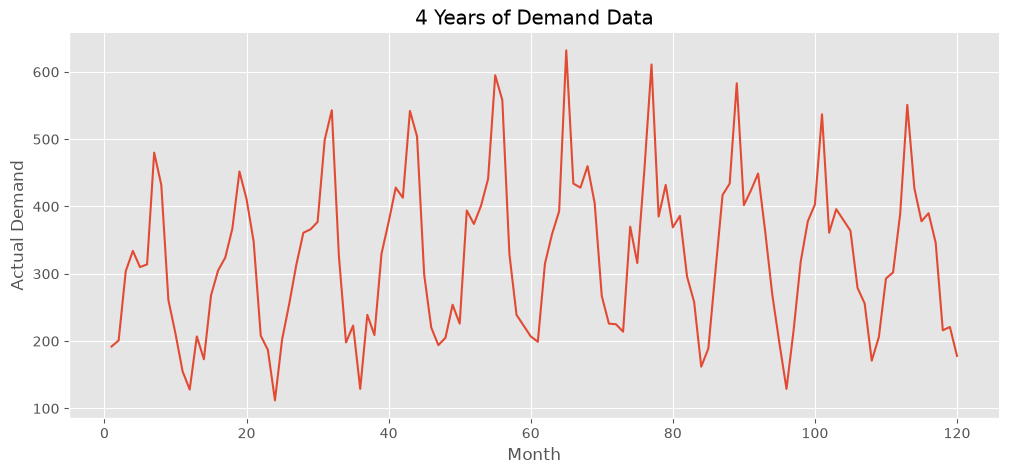

In [5]:
fig, ax = plt.subplots(figsize=(12,5))
sns.lineplot(x="months",
			 y="act_demand",
			 data=df,
			 legend=False,
			 ax=ax)
plt.xlabel("Month"),
plt.ylabel("Actual Demand")
plt.title("4 Years of Demand Data");

- test data

In [6]:
test_data=df.loc[86:, "act_demand"]

- Results Table Initiation

In [7]:
As = []
Bs = []
alphas = []
betas = []
phis = []
gammas = []
train_residuals_means = []
train_r2s = []
train_WMAPEs = []
test_residuals_means = []
test_r2s = []
test_WMAPEs = []

# Holt's Winter Model --> $(a+bx)*F$

## A. When init_data is initial part of train data 

### 1. Data division

In [8]:
init_data = df.loc[:37, "act_demand"]
train_data = df.loc[:85, "act_demand"]

### 2. Model construction (init)

In [9]:
init = ES(
	endog=init_data,
	
	trend="add",
	# damped_trend=True,
	
	seasonal="mul",
	seasonal_periods=months,
	
	initialization_method="heuristic"
)

### 3. Fitting the model

In [10]:
results = init.fit()

### 4. Getting factors of level, trend and seasonality

In [11]:
a0 = results.params['initial_level']
b0 = results.params['initial_trend']
Fs = results.params['initial_seasons']

print("Initial level is: ", a0)
print("Initial trend is: ", b0)
print("Initial seasonality factors are: ", "\n", pd.Series(Fs))

As.append(a0)
Bs.append(b0)

Initial level is:  274.3999999999998
Initial trend is:  0.04848484848486612
Initial seasonality factors are:  
 0     0.712496
1     0.730726
2     0.986715
3     1.126098
4     1.163662
5     1.252268
6     1.673590
7     1.506938
8     1.079909
9     0.744468
10    0.601625
11    0.421504
dtype: float64


### 5. Model construction (train)

In [12]:
train = ES(
	endog=train_data,
	
	trend="add",
	damped_trend=True,
	
	seasonal="mul",
	seasonal_periods=months,
	
	initialization_method="known",

	initial_level=a0, 
	initial_trend=b0,
	initial_seasonal=Fs
)

### 6. Getting parameters (alpha, beta, gamma)

In [13]:
results = train.fit(optimized=True, remove_bias=True)

In [14]:
alpha = results.params['smoothing_level']
beta = results.params['smoothing_trend']
phi = results.params['damping_trend']
gamma = results.params['smoothing_seasonal']

print("Level parameter, alpha is: ", round(alpha, 2))
print("Trend parameter, beta is: ", round(beta, 2))
print("Dampening parameter, phi is: ", round(phi, 2))
print("Seasonality parameter, gamma is: ", round(gamma, 2))

alphas.append(alpha)
betas.append(beta)
phis.append(phi)
gammas.append(gamma)

Level parameter, alpha is:  0.06
Trend parameter, beta is:  0.0
Dampening parameter, phi is:  0.99
Seasonality parameter, gamma is:  0.7


### 7. Forecasting

In [15]:
y_pred_train = results.fittedvalues
y_pred = results.forecast(steps=len(test_data))

### 8. Train residuals and train Scores

In [16]:
residuals_train = train_data - y_pred_train
# residuals_test = test_data - y_pred

r2 = r2_score(train_data, y_pred_train)
WMAPE = mean_absolute_percentage_error(train_data, y_pred_train, sample_weight=train_data)

print("Train residuals average is: ", residuals_train.mean().round(0))
print("R2 score of the train data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the train data is: ", round(WMAPE, 2)*100, "%")

train_residuals_means.append(residuals_train.mean())
train_r2s.append(r2)
train_WMAPEs.append(WMAPE)

Train residuals average is:  -0.0
R2 score of the train data is:  82.0 %
WMAPE score of the train data is:  11.0 %


### 9. Test residuals and test scores

In [17]:
residuals_test = test_data - y_pred

r2 = r2_score(test_data, y_pred)
WMAPE = mean_absolute_percentage_error(test_data, y_pred, sample_weight=test_data)

print("Test residuals average is: ", residuals_test.mean().round(0))
print("R2 score of the test data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the test data is: ", round(WMAPE, 2)*100, "%")

test_residuals_means.append(residuals_test.mean())
test_r2s.append(r2)
test_WMAPEs.append(WMAPE)

Test residuals average is:  -15.0
R2 score of the test data is:  88.0 %
WMAPE score of the test data is:  9.0 %


## B. When init_data is NOT A PART of train data 

### 1. Data division

In [18]:
init_data = df.loc[:36, "act_demand"]
train_data = df.loc[37:85, "act_demand"]

In [19]:
init_data.tail()

32    326
33    198
34    223
35    129
36    239
Name: act_demand, dtype: int64

In [20]:
train_data.head()

37    209
38    330
39    377
40    428
41    413
Name: act_demand, dtype: int64

These steps are the same as before:

2. Model construction (init)

3. Fitting the model

4. Getting factors of level, trend and seasonality

- Intermediate step for level adaptation

In [21]:
a0 = a0 + b0*36

print("The level at t=36 for t=37 is: ", a0)

As.append(a0)
Bs.append(b0)

The level at t=36 for t=37 is:  276.145454545455


### 5. Model construction (train)

In [22]:
train = ES(
	endog=train_data,
	
	trend="add",
	damped_trend=True,
	
	seasonal="mul",
	seasonal_periods=months,
	
	initialization_method="known",

	initial_level=a0, 
	initial_trend=b0,
	initial_seasonal=Fs
)

### 6. Getting parameters (alpha, beta, gamma)

In [23]:
results = train.fit(optimized=True, remove_bias=True)

In [24]:
alpha = results.params['smoothing_level']
beta = results.params['smoothing_trend']
phi = results.params['damping_trend']
gamma = results.params['smoothing_seasonal']

print("Level parameter, alpha is: ", round(alpha, 2))
print("Trend parameter, beta is: ", round(beta, 2))
print("Dampening parameter, phi is: ", round(phi, 2))
print("Seasonality parameter, gamma is: ", round(gamma, 2))

alphas.append(alpha)
betas.append(beta)
phis.append(phi)
gammas.append(gamma)

Level parameter, alpha is:  0.04
Trend parameter, beta is:  0.0
Dampening parameter, phi is:  0.92
Seasonality parameter, gamma is:  0.79


### 7. Forecasting

In [25]:
y_pred_train = results.fittedvalues
y_pred = results.forecast(steps=len(test_data))

### 8. Train residuals and train Scores

In [26]:
residuals_train = train_data - y_pred_train
# residuals_test = test_data - y_pred

r2 = r2_score(train_data, y_pred_train)
WMAPE = mean_absolute_percentage_error(train_data, y_pred_train, sample_weight=train_data)

print("Train residuals average is: ", residuals_train.mean().round(0))
print("R2 score of the train data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the train data is: ", round(WMAPE, 2)*100, "%")

train_residuals_means.append(residuals_train.mean())
train_r2s.append(r2)
train_WMAPEs.append(WMAPE)

Train residuals average is:  0.0
R2 score of the train data is:  61.0 %
WMAPE score of the train data is:  16.0 %


### 9. Test residuals and test Scores

In [27]:
residuals_test = test_data - y_pred

r2 = r2_score(test_data, y_pred)
WMAPE = mean_absolute_percentage_error(test_data, y_pred, sample_weight=test_data)

print("Test residuals average is: ", residuals_test.mean().round(0))
print("R2 score of the test data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the test data is: ", round(WMAPE, 2)*100, "%")

test_residuals_means.append(residuals_test.mean())
test_r2s.append(r2)
test_WMAPEs.append(WMAPE)

Test residuals average is:  -19.0
R2 score of the test data is:  86.0 %
WMAPE score of the test data is:  10.0 %


## C. When only train data used - heuristic

Data division is the same as above (only train_data will be used)
1. Data division

As init data will not be used, the steps below are not necessary anymore:

2. Model construction (init)

3. Fitting the model

4. Getting factors of level, trend and seasonality

### 5. Model construction (train)

In [28]:
train = ES(
	endog=train_data,
	
	trend="add",
	damped_trend=True,
	
	seasonal="mul",
	seasonal_periods=months,
	
	initialization_method="heuristic",
)

### 6. Getting factors of level, trend and seasonality AND Getting parameters (alpha, beta, gamma)

In [29]:
results = train.fit(optimized=True, remove_bias=True)

In [30]:
a0 = results.params['initial_level']
b0 = results.params['initial_trend']
Fs = results.params['initial_seasons']

print("Initial level is: ", a0)
print("Initial trend is: ", b0)
print("Initial seasonality factors are: ", "\n", pd.Series(Fs))

alpha = results.params['smoothing_level']
beta = results.params['smoothing_trend']
phi = results.params['damping_trend']
gamma = results.params['smoothing_seasonal']

print("Level parameter, alpha is: ", round(alpha, 2))
print("Trend parameter, beta is: ", round(beta, 2))
print("Dampening parameter, phi is: ", round(phi, 2))
print("Seasonality parameter, gamma is: ", round(gamma, 2))

As.append(a0)
Bs.append(b0)

alphas.append(alpha)
betas.append(beta)
phis.append(phi)
gammas.append(gamma)

Initial level is:  329.26388888888874
Initial trend is:  2.189898989899005
Initial seasonality factors are:  
 0     0.854977
1     1.009314
2     1.145167
3     1.529886
4     1.173828
5     1.363316
6     1.450636
7     0.973459
8     0.683451
9     0.599388
10    0.591633
11    0.624943
dtype: float64
Level parameter, alpha is:  0.0
Trend parameter, beta is:  0.0
Dampening parameter, phi is:  0.93
Seasonality parameter, gamma is:  0.0


### 7. Forecasting

In [31]:
y_pred_train = results.fittedvalues
y_pred = results.forecast(steps=len(test_data))

### 8. Train residuals and train Scores

In [32]:
residuals_train = train_data - y_pred_train

r2 = r2_score(train_data, y_pred_train)
WMAPE = mean_absolute_percentage_error(train_data, y_pred_train, sample_weight=train_data)

print("Train residuals average is: ", residuals_train.mean().round(0))
print("R2 score of the train data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the train data is: ", round(WMAPE, 2)*100, "%")

train_residuals_means.append(residuals_train.mean())
train_r2s.append(r2)
train_WMAPEs.append(WMAPE)

Train residuals average is:  -0.0
R2 score of the train data is:  81.0 %
WMAPE score of the train data is:  11.0 %


### 9. Test residuals and test scores

In [33]:
residuals_test = test_data - y_pred

r2 = r2_score(test_data, y_pred)
WMAPE = mean_absolute_percentage_error(test_data, y_pred, sample_weight=test_data)

print("Test residuals average is: ", residuals_test.mean().round(0))
print("R2 score of the test data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the test data is: ", round(WMAPE, 2)*100, "%")

test_residuals_means.append(residuals_test.mean())
test_r2s.append(r2)
test_WMAPEs.append(WMAPE)

Test residuals average is:  -19.0
R2 score of the test data is:  78.0 %
WMAPE score of the test data is:  11.0 %


## D. When only train data used - estimated

Data division is the same as above (only train_data will be used)
1. Data division

As init data will not be used, the steps below are not necessary anymore:

2. Model construction (init)

3. Fitting the model

4. Getting factors of level, trend and seasonality

### 5. Model construction (train)

In [34]:
train = ES(
	endog=train_data,
	
	trend="add",
	damped_trend=True,
	
	seasonal="mul",
	seasonal_periods=months,
	
	initialization_method="estimated",
)

### 6. Getting factors of level, trend and seasonality AND Getting parameters (alpha, beta, gamma)

In [35]:
results = train.fit(optimized=True, remove_bias=True)

In [36]:
a0 = results.params['initial_level']
b0 = results.params['initial_trend']
Fs = results.params['initial_seasons']

print("Initial level is: ", a0)
print("Initial trend is: ", b0)
print("Initial seasonality factors are: ", "\n", pd.Series(Fs))

alpha = results.params['smoothing_level']
beta = results.params['smoothing_trend']
phi = results.params['damping_trend']
gamma = results.params['smoothing_seasonal']

print("Level parameter, alpha is: ", round(alpha, 2))
print("Trend parameter, beta is: ", round(beta, 2))
print("Dampening parameter, phi is: ", round(phi, 2))
print("Seasonality parameter, gamma is: ", round(gamma, 2))

As.append(a0)
Bs.append(b0)

alphas.append(alpha)
betas.append(beta)
phis.append(phi)
gammas.append(gamma)

Initial level is:  329.1014384521195
Initial trend is:  25.7384418390055
Initial seasonality factors are:  
 0     0.690731
1     0.841844
2     0.955684
3     1.234762
4     0.987817
5     1.172551
6     1.107461
7     0.831093
8     0.597058
9     0.525360
10    0.464773
11    0.497097
dtype: float64
Level parameter, alpha is:  0.0
Trend parameter, beta is:  0.0
Dampening parameter, phi is:  0.8
Seasonality parameter, gamma is:  0.0


### 7. Forecasting

In [37]:
y_pred_train = results.fittedvalues
y_pred = results.forecast(steps=len(test_data))

### 8. Train residuals and train Scores

In [38]:
residuals_train = train_data - y_pred_train

r2 = r2_score(train_data, y_pred_train)
WMAPE = mean_absolute_percentage_error(train_data, y_pred_train, sample_weight=train_data)

print("Train residuals average is: ", residuals_train.mean().round(0))
print("R2 score of the train data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the train data is: ", round(WMAPE, 2)*100, "%")

train_residuals_means.append(residuals_train.mean())
train_r2s.append(r2)
train_WMAPEs.append(WMAPE)

Train residuals average is:  0.0
R2 score of the train data is:  83.0 %
WMAPE score of the train data is:  11.0 %


### 9. Test residuals and test scores

In [39]:
residuals_test = test_data - y_pred

r2 = r2_score(test_data, y_pred)
WMAPE = mean_absolute_percentage_error(test_data, y_pred, sample_weight=test_data)

print("Test residuals average is: ", residuals_test.mean().round(0))
print("R2 score of the test data is: ", round(r2, 2)*100, "%")
print("WMAPE score of the test data is: ", round(WMAPE, 2)*100, "%")

test_residuals_means.append(residuals_test.mean())
test_r2s.append(r2)
test_WMAPEs.append(WMAPE)

Test residuals average is:  -21.0
R2 score of the test data is:  80.0 %
WMAPE score of the test data is:  10.0 %


# Comparison 

In [40]:
comparison = pd.DataFrame({
	"level_factor": As,
	"trend_factor": Bs,
	"level_parameter": alphas,
	"trend_parameter": betas,
	"dampening_parameter": phis,
	"seasonality_parameter": gammas,
	"train_residual_mean": train_residuals_means,
	"train_r2_score": train_r2s,
	"train_WMAPE": train_WMAPEs,
	"test_residual_mean": test_residuals_means,
	"test_r2_score": test_r2s,
	"test_WMAPE": test_WMAPEs,
	
}).T

comparison.columns = ["heuristic, init ⊂ train", "heuristic, init ⊄ train", "heuristic, no init", "estimated, no init"]
comparison = (comparison
	.style
	.format(precision=3)
	.highlight_max(color='blue', subset=pd.IndexSlice[["test_r2_score"] , :], axis=1)
	.highlight_min(color="blue", subset=pd.IndexSlice[["test_WMAPE"], :], axis=1)
	)
comparison

,"heuristic, init ⊂ train","heuristic, init ⊄ train","heuristic, no init","estimated, no init"
level_factor,274.400,276.145,329.264,329.101
trend_factor,0.048,0.048,2.190,25.738
level_parameter,0.055,0.043,0.000,0.000
trend_parameter,0.000,0.000,0.000,0.000
dampening_parameter,0.986,0.923,0.925,0.800
seasonality_parameter,0.705,0.789,0.000,0.000
train_residual_mean,-0.000,0.000,-0.000,0.000
train_r2_score,0.823,0.612,0.810,0.833
train_WMAPE,0.107,0.158,0.114,0.111
test_residual_mean,-15.042,-19.044,-19.401,-20.666
